# Exploratory Data Analysis

EDA Outline: 
1. Importing and understanding the data
2. Data Cleaning </br>
    a. Checking and handling missing values </br>
    b. Checking and handling duplicates </br>
    c. Fixing target variable </br>
    d. Outlier analysis 
2. Distributions and Relationships </br>
    a. Categorical variable distribution </br>
    b. Continuous variable distribution </br>
    c. Relationship between categorical and continuous variables </br>
3. Data Preprocessing </br>
    a. Encoding categorical columns and standardizing numerical columns 


## Data Ingestion

In [1]:
import json
from ucimlrepo import fetch_ucirepo

heart_disease = fetch_ucirepo(id=45)

# Convert data to a pandas Dataframe 
X = heart_disease.data.features
y = heart_disease.data.targets

# Metadata
print("-------Metadata------")
print(json.dumps(heart_disease.metadata, indent=4))


-------Metadata------
{
    "uci_id": 45,
    "name": "Heart Disease",
    "repository_url": "https://archive.ics.uci.edu/dataset/45/heart+disease",
    "data_url": "https://archive.ics.uci.edu/static/public/45/data.csv",
    "abstract": "4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach",
    "area": "Health and Medicine",
    "tasks": [
        "Classification"
    ],
    "characteristics": [
        "Multivariate"
    ],
    "num_instances": 303,
    "num_features": 13,
    "feature_types": [
        "Categorical",
        "Integer",
        "Real"
    ],
    "demographics": [
        "Age",
        "Sex"
    ],
    "target_col": [
        "num"
    ],
    "index_col": null,
    "has_missing_values": "yes",
    "missing_values_symbol": "NaN",
    "year_of_dataset_creation": 1989,
    "last_updated": "Fri Nov 03 2023",
    "dataset_doi": "10.24432/C52P4X",
    "creators": [
        "Andras Janosi",
        "William Steinbrunn",
        "Matthias Pfisterer",
        

In [2]:
import pandas as pd 

df = pd.concat((X,y), axis=1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [3]:
from pathlib import Path
import os 

# Save data to csv file
data_filepath = Path("data/heart_disease_data.csv")
if not os.path.exists(data_filepath):
    df.to_csv("data/heart_disease_data.csv")

In [4]:
# Data Summarization 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


Variables or features explanations:

- age (Age in years)
- sex : (1 = male, 0 = female)
- cp (Chest Pain Type): [ 0: asymptomatic, 1: atypical angina, 2: non-anginal pain, 3: typical angina]
- trestbps (Resting Blood Pressure in mm/hg )
- chol (Serum Cholesterol in mg/dl)
- fps (Fasting Blood Sugar > 120 mg/dl): [0 = no, 1 = yes]
- restecg (Resting ECG): [0: showing probable or definite left ventricular hypertrophy by Estes’ criteria, 1: normal, 2: having ST-T wave abnormality]
- thalach (maximum heart rate achieved)
- exang (Exercise Induced Angina): [1 = yes, 0 = no]
- oldpeak (ST depression induced by exercise relative to rest)
- slope (the slope of the peak exercise ST segment): [0: downsloping; 1: flat; 2: upsloping]
- ca [number of major vessels (0–3)
- thal : [1 = normal, 2 = fixed defect, 3 = reversible defect]
- Target (num) : 
    - 0: No presence of heart disease (normal angiogram).
    - 1: Mild/Stage 1 heart disease (1 major vessel narrowed).
    - 2: Moderate/Stage 2 heart disease (2 major vessels narrowed).
    - 3: Severe/Stage 3 heart disease (3 major vessels narrowed).
    - 4: Very severe/Stage 4 heart disease (4 major vessels narrowed)

In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


## Data Cleaning

> Resource: https://medium.com/@tarangds/how-to-identify-missing-data-a-detailed-guide-a33dde4889bb 

### Checking for missing values

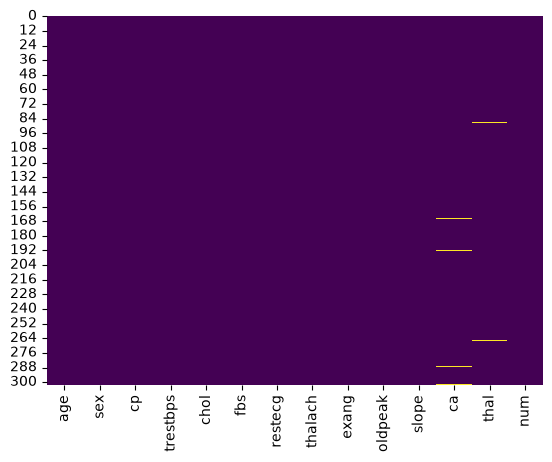

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt 

# Heatmap for missing values per column 
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()



In [7]:
# Number of missing values per column 
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


- As the heatmap shows and missing values count show, missing values only appear in columns:   `ca` and `thal `
- Before applying any solution let's test the missing data mechanisms to understand how to handle the missing data 
    - Missing data can fall into 3 categories:
        1. MCAR (Missing Completely at Random) - Missing data is unrelated to both observed and unobserved data
        2. MAR (Missing at Random) - Missing data is related to observed data but not to missing values 
        3. MNAR (Missing Not at Random) - Missing data is related to the unobserved values themselves
    - However, tests for these mechanisms such as [Little's MCAR test](https://medium.com/@tarangds/understanding-littles-mcar-test-a-key-tool-in-missing-data-analysis-47fd70698149) need more missing data to determine any relationship between the missing data and observed/unobserved data (we only have 6 missing values)
    - Instead we will skip these test and move onto handling the missing values


### Handling Missing Values 

In [8]:
# Inspecting missing values 
print(df[df.isna().any(axis=1)])

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
87    53    0   3       128   216    0        2      115      0      0.0   
166   52    1   3       138   223    0        0      169      0      0.0   
192   43    1   4       132   247    1        2      143      1      0.1   
266   52    1   4       128   204    1        0      156      1      1.0   
287   58    1   2       125   220    0        0      144      0      0.4   
302   38    1   3       138   175    0        0      173      0      0.0   

     slope   ca  thal  num  
87       1  0.0   NaN    0  
166      1  NaN   3.0    0  
192      2  NaN   7.0    1  
266      2  0.0   NaN    2  
287      2  NaN   7.0    0  
302      1  NaN   3.0    0  


Given the little amount of missing values compared to the full dataset (6 missing values in a datasets with 303 rows) we can drop them without major effects on downstream model training

In [9]:
df = df.dropna()
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


### Checking for Duplicate data 

In [10]:
duplicates = df.duplicated().sum()
if duplicates:
    print("Duplicate Rows in dataset are: {}".format(duplicates))
else: 
    print('Dataset contains no duplicate values')

Dataset contains no duplicate values


### Fixing target variable

Since I am planning to use Logistic Regression as a baseline, the taget variable needs to be fixed, why?

- Logistic Regression is used when the outcome is binary, but in this dataset the stage of the heart disease diagnosis (1-4) is also noted. We only need to keep it as 0 and 1
- To fix this any value greater than 0 will become 1 to signify a diagnosis

In [11]:
df.loc[df["num"]>0, 'num'] = 1

print(df["num"].nunique())

2


### Outlier Analysis

Defining and listing outliers

In [12]:
import numpy as np

continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

def outliers(df_out : pd.DataFrame, drop = False):
    for each_feature in df_out.columns: 
        feature_data = df_out[each_feature]
        Q1 = np.percentile(feature_data, 25.)
        Q3 = np.percentile(feature_data, 75.)
        IQR = Q3-Q1
        outlier_step = IQR * 1.5
        outliers = feature_data[~((feature_data >= Q1 - outlier_step) & (feature_data <= Q3 + outlier_step))].index.tolist()
        if not drop: 
            print('For feature {}, # of outliers is {}'.format(each_feature, len(outliers)))
        if drop:
            df.drop(outliers, inplace=True, errors='ignore')
            print('Outliers from {} feature removed '.format(each_feature))

outliers(df[continuous_features])
outliers(df[continuous_features], drop=True)

For feature age, # of outliers is 0
For feature trestbps, # of outliers is 9
For feature chol, # of outliers is 5
For feature thalach, # of outliers is 1
For feature oldpeak, # of outliers is 5
Outliers from age feature removed 
Outliers from trestbps feature removed 
Outliers from chol feature removed 
Outliers from thalach feature removed 
Outliers from oldpeak feature removed 


## Distributions & Relationship

Target variable distribution

num
0    154
1    124
Name: count, dtype: int64


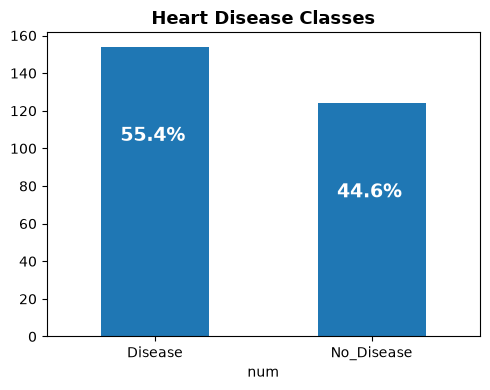

In [13]:
print(df.num.value_counts())

fig, ax = plt.subplots(figsize=(5,4))
name = ["Disease", "No_Disease"]
ax = df.num.value_counts().plot(kind='bar')
ax.set_title("Heart Disease Classes", fontsize=13, weight='bold')
ax.set_xticklabels(name, rotation=0)

# Calculate percentage
totals = []
for i in ax.patches:
    totals.append(i.get_height())
total = sum(totals)
for i in ax.patches:
    ax.text(i.get_x()+.09, i.get_height()-50, \
            str(round((i.get_height()/total)*100, 2))+'%', fontsize=14,
                color='white', weight = 'bold')

plt.tight_layout()


Age variable distribution

Text(0.5, 1.0, 'Age Distribution')

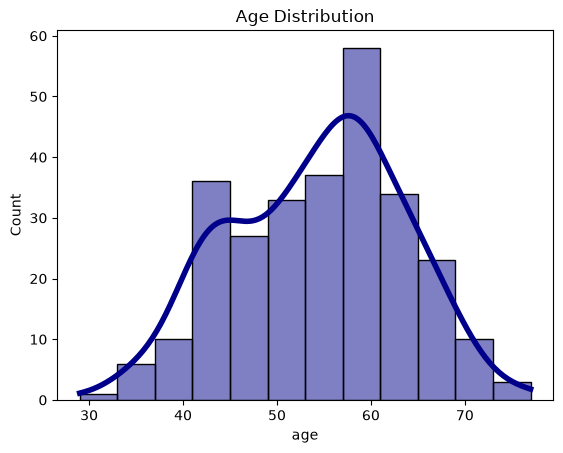

In [14]:
# print(df.age.value_counts())
sns.histplot(
    df.age,
    kde=True, # Kernel Density Estimation
    color="darkblue",
    line_kws={"linewidth": 4}
)

plt.title('Age Distribution')

In [15]:
print(min(df.age))
print(max(df.age))
print(df.age.mean())

29
77
54.172661870503596


Gender distribution according to target variable

/var/folders/f9/xx_tnkhj4lx3ylbk98sjxw7h0000gn/T/ipykernel_92571/676084652.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels (name, rotation = 0)


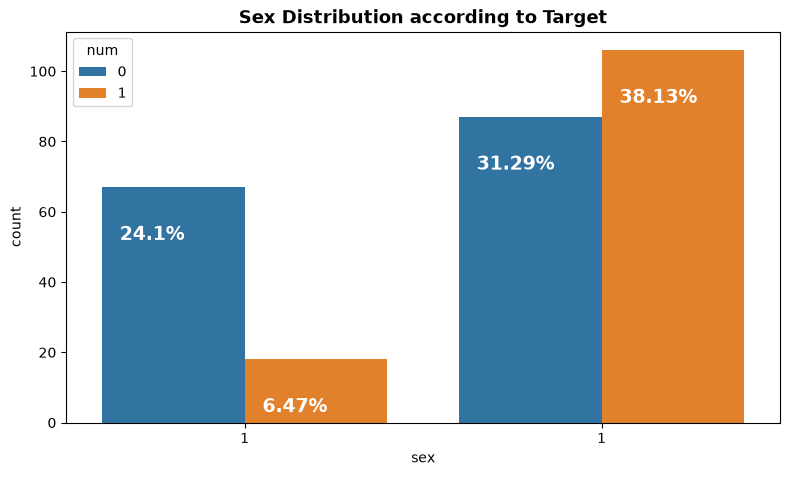

In [16]:
fig, ax = plt.subplots(figsize=(8,5))
name = df['sex']
ax = sns.countplot(x='sex', hue='num', data=df)
ax.set_title("Sex Distribution according to Target", fontsize = 13, weight = 'bold')
ax.set_xticklabels (name, rotation = 0)

totals = []
for i in ax.patches:
    totals.append(i.get_height())
total = sum(totals)
for i in ax.patches:
    ax.text(i.get_x()+.05, i.get_height()-15,
            str(round((i.get_height()/total)*100, 2))+'%', fontsize=14,
                color='white', weight = 'bold')  
plt.tight_layout()

Chest pain distribution according to target variable


/var/folders/f9/xx_tnkhj4lx3ylbk98sjxw7h0000gn/T/ipykernel_92571/2675128617.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels (name, rotation = 0)


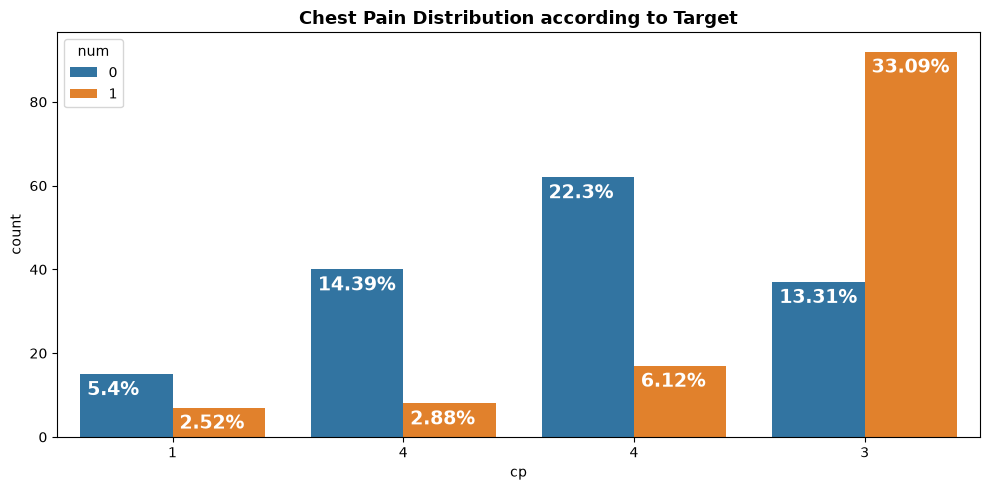

In [17]:
fig, ax = plt.subplots(figsize=(10,5))
name = df['cp']
ax = sns.countplot(x='cp', hue='num', data=df)
ax.set_title("Chest Pain Distribution according to Target", fontsize = 13, weight = 'bold')
ax.set_xticklabels (name, rotation = 0)

totals = []
for i in ax.patches:
    totals.append(i.get_height())
total = sum(totals)
for i in ax.patches:
    ax.text(i.get_x()+.03, i.get_height()-5,
            str(round((i.get_height()/total)*100, 2))+'%', fontsize=14,
                color='white', weight = 'bold')  
plt.tight_layout()


Correlation between variables

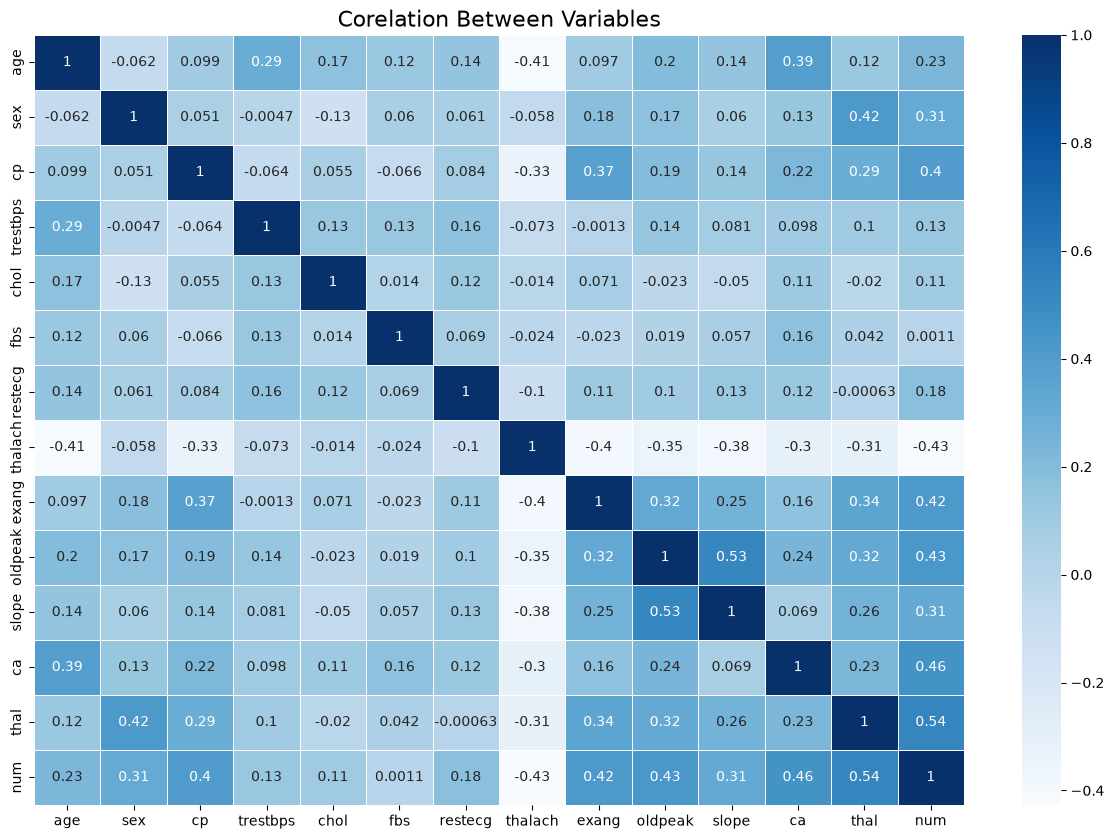

In [18]:
plt.rcParams['figure.figsize'] = (15, 10) 
sns.heatmap(df.corr(), annot = True, linewidths=.5, cmap="Blues")
plt.title('Corelation Between Variables', fontsize = 16)
plt.show()

## Data Preprocessing

### Encoding columns

Let's first look into the variable information to confirm what needs to be encoded (only categorical variables)

In [19]:
# Variable Information
print("\n----------Variable Information------------")
print(heart_disease.variables)


----------Variable Information------------
        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical         NaN   
3   trestbps  Feature      Integer         NaN   
4       chol  Feature      Integer         NaN   
5        fbs  Feature  Categorical         NaN   
6    restecg  Feature  Categorical         NaN   
7    thalach  Feature      Integer         NaN   
8      exang  Feature  Categorical         NaN   
9    oldpeak  Feature      Integer         NaN   
10     slope  Feature  Categorical         NaN   
11        ca  Feature      Integer         NaN   
12      thal  Feature  Categorical         NaN   
13       num   Target      Integer         NaN   

                                          description  units missing_values  
0                                                 NaN  years             no  
1                                                

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define which columns go to which transformer
one_hot_cols = ["cp", "restecg","slope", "thal"]
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]


# Makes a pipeline to apply transformations to specified columns 
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), one_hot_cols), # One hot encoding applied to one_hot_cols, sparse_output=False to easily convert the output back into a readable array or DataFrame
    ("num", StandardScaler(), numeric_cols), # Standardize features by removing mean and then scaling to unit variance
], 
remainder="passthrough", # remainder=passthrough leaves remaining (sex, fbs and exang) columns as is since there are already binary variables so no need for encoding
verbose_feature_names_out=False) # Turns off prefixes above "cat__", "num__" and "remainder__" for column names

processed_data = preprocess.fit_transform(df)

# Convert output back into a Pandas DataFrame with explicit column names
processed_data = pd.DataFrame(processed_data, columns=preprocess.get_feature_names_out())


processed_data.head()

,cp_1,cp_2,cp_3,cp_4,restecg_0,restecg_1,restecg_2,slope_1,slope_2,slope_3,...,age,trestbps,chol,thalach,oldpeak,ca,sex,fbs,exang,num
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.967884,0.966617,-0.226405,0.000000,1.299011,-0.717120,1.0,1.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.406469,1.930000,0.956100,-1.851258,0.521353,2.587179,1.0,0.0,1.0,1.0
2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.406469,-0.639021,-0.315650,-0.925629,1.590633,1.485746,1.0,0.0,1.0,1.0
3,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-1.882917,0.003234,0.152889,1.630871,2.465498,-0.717120,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,-1.444332,0.003234,-0.873435,0.969707,0.424145,-0.717120,0.0,0.0,0.0,0.0


Now we can save the preprocessed dataset to a new csv for model training

In [21]:
if not os.path.exists("data/processed_data.csv"):
    processed_data.to_csv("data/processed_data.csv")

Save the preprocesser for streamlit app predictions

In [22]:
from joblib import dump

features = df.drop(columns="num")
preprocess.fit(features)
dump(preprocess, "models/preprocessor.joblib")

['models/preprocessor.joblib']